In [23]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.rcParams['font.size'] = '10'

In [24]:
df = pd.read_csv('data.csv')
# Convert Ship Date, Order Date column data types from object to datetime
df['Order Date'] = df['Order Date'].astype('datetime64[ns]')
df['Ship Date Date'] = df['Ship Date'].astype('datetime64[ns]')

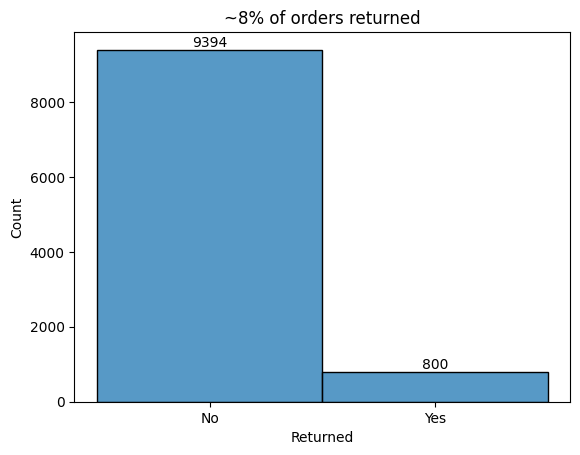

In [253]:
# Number of products returned
ax = sns.histplot(df['Returned'])
plt.title('~8% of orders returned')
ax.bar_label(ax.containers[0])
plt.show()

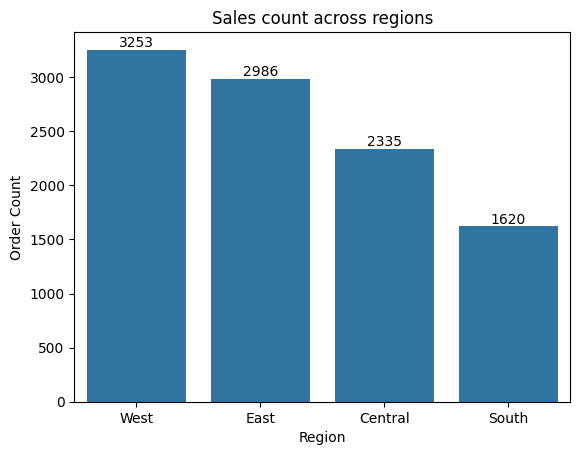

In [226]:
# Sales count across regions
sales_by_region=df.groupby('Region')['Order ID'].count().to_frame(name='Order Count').sort_values('Order Count',ascending=False)
# sales_by_region.plot.bar(use_index=True)
# plt.title('Order count by region')
# plt.show()
ax=sns.barplot(x=sales_by_region.index,y=sales_by_region['Order Count'],data=sales_by_region)
ax.bar_label(ax.containers[0])
plt.title('Sales count across regions')
plt.show()

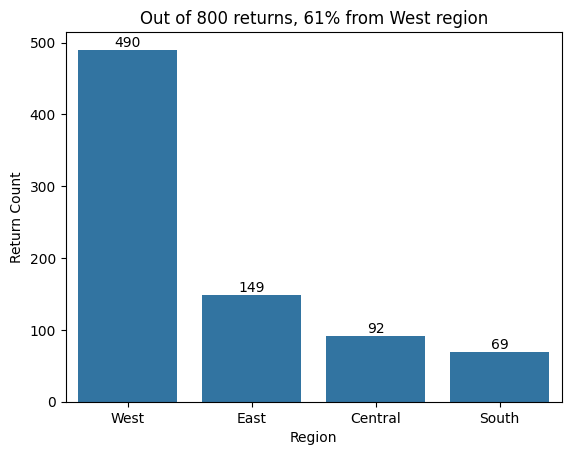

In [257]:
# Return count across regions
return_by_region = df[df['Returned']=='Yes']
return_by_region=return_by_region.groupby('Region')['Returned'].count().to_frame(name='Return Count').sort_values('Return Count',ascending=False)
ax = sns.barplot(x=return_by_region.index,y=return_by_region['Return Count'])
ax.bar_label(ax.containers[0])
plt.title('Out of 800 returns, 61% from West region')
plt.show()

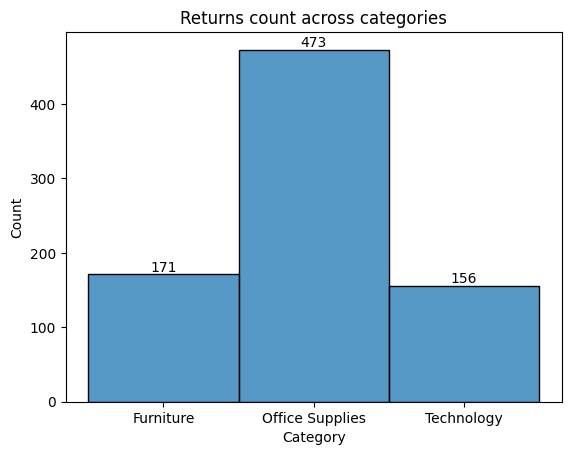

In [37]:
# Return count across categories
ax=sns.histplot(x=returned_df['Category'])
plt.title('Returns count across categories')
ax.bar_label(ax.containers[0])
plt.show()

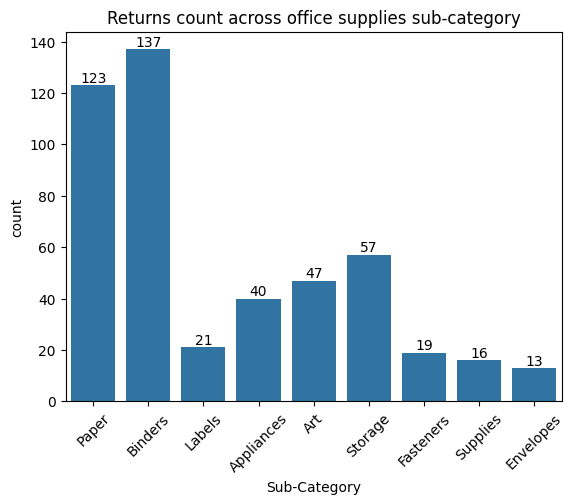

In [260]:
# Return count across office supplies category
office_supply = returned_df[returned_df['Category']=='Office Supplies']
ax=sns.countplot(x=office_supply['Sub-Category'])
plt.title('Returns count across office supplies sub-category')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.show()

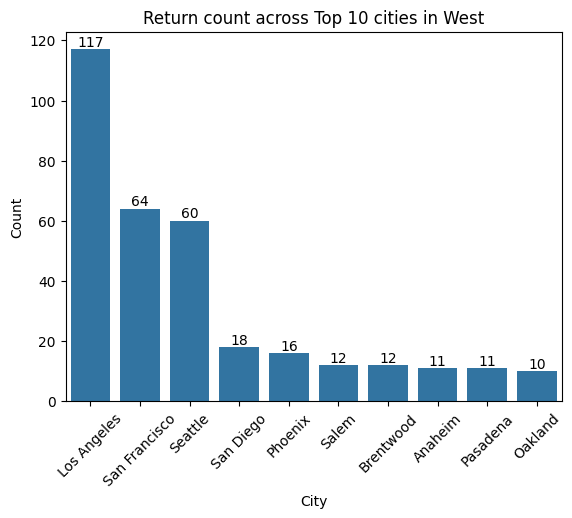

In [236]:
# Returns across cities in West region
west_returns = df[(df['Region'] == 'West') & (df['Returned'] == 'Yes')]
corr_matrix = west_returns[['City','Returned']]
hm=corr_matrix.groupby('City')['Returned'].count().to_frame(name='Count').sort_values('Count',ascending=False)[:10]
# hm.plot.bar(use_index=True)
ax = sns.barplot(x=hm.index,y=hm['Count'])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.title('Return count across Top 10 cities in West')
plt.show()

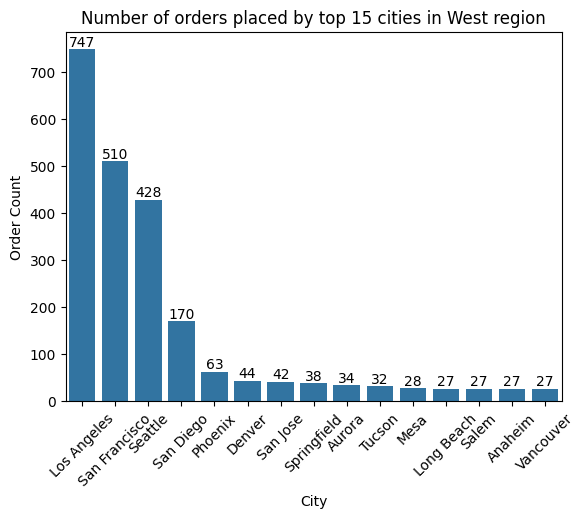

In [272]:
# Number of orders for each city in West region
west_city_orders = df[df['Region']=='West'].groupby('City')['Order ID'].count().to_frame(name='Order Count').sort_values('Order Count',ascending=False)[:15]
ax = sns.barplot(x=west_city_orders.index,y=west_city_orders['Order Count'])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.title('Number of orders placed by top 15 cities in West region')
plt.show()

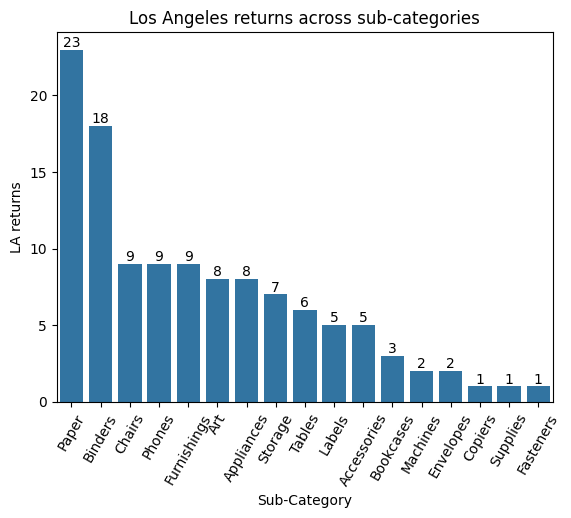

In [273]:
los_angeles_returns = df[df['City']=='Los Angeles']
los_angeles_returns = los_angeles_returns[los_angeles_returns['Returned']=='Yes']
# los_angeles_returns.groupby('Sub-Category')['Category'].count().to_frame(name='LA returns').sort_values('LA returns',ascending=False).plot.bar(use_index=True)
los_angeles_returns = los_angeles_returns.groupby('Sub-Category')['Category'].count().to_frame(name='LA returns').sort_values('LA returns',ascending=False)
ax = sns.barplot(x=los_angeles_returns.index, y=los_angeles_returns['LA returns'])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=60)
plt.title('Los Angeles returns across sub-categories')
plt.show()

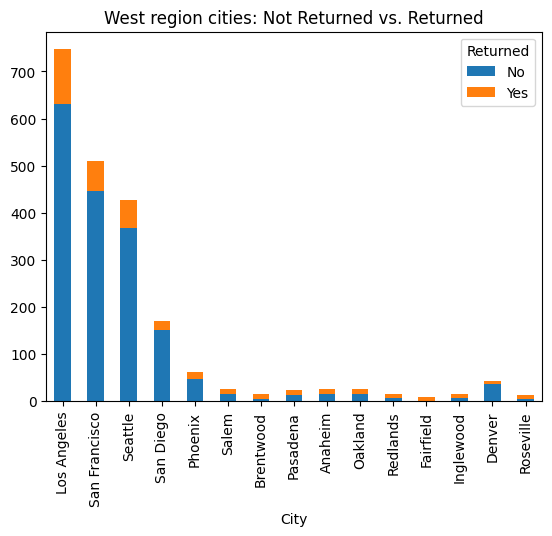

In [330]:
# West region cities: Not Returned vs. Returned
returns_across_city = df[df['Region']=='West']
returns_across_city = returns_across_city[['City','Returned']]
dt=pd.crosstab(returns_across_city['City'],returns_across_city['Returned'])
return_west_city=dt.sort_values('Yes', ascending=False)[:15]
return_west_city.plot(kind='bar',stacked=True)
plt.title('West region cities: Not Returned vs. Returned')
plt.show()